In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bioviper import selector 

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

import pickle 

from studio_analysis_tools import *

In [10]:
#scores_path = "/Users/sam/Dropbox (Harvard University)/SpecificityStudio/all_scores.pkl"
scores_path = "/Users/sam/Downloads/all_scores(7).pkl"

with open(scores_path, 'rb') as infile:
    all_scores = pickle.load(infile)
    
for prot,dataset in all_scores.items():
    if 'EVE' in dataset:
        dataset.loc[:,'EVE'] = -dataset['EVE']

# Part one: boxplot o'clock

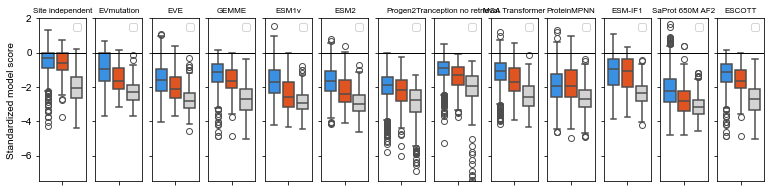

In [3]:
model_names = ['Site_independent', "EVmutation", "EVE", "GEMME", "ESM1v", "ESM2", "Progen2", "Tranception_no_retrieval", "MSA_Transformer", "ProteinMPNN", "ESM-IF1", "SaProt_650M_AF2", "ESCOTT"]
data = all_scores['DLG4_HUMAN_Zarin_2024'].copy()
data.loc['WT'] = data.loc['WT'].fillna(0)
fig, ax = StudioBoxplots(data, model_names, standardize_to_wt=True);
for axis in ax:
    axis.set_ylim(-7.5,2)
    
plt.savefig('PDZ_boxplots.pdf', bbox_inches='tight', dpi=300)

In [4]:
!pwd

/Users/sam/Harvard University Dropbox/Samuel Berry/SpecificityStudio/notebooks


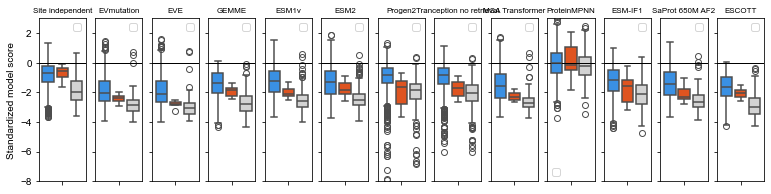

In [5]:
model_names = ['Site_independent', "EVmutation", "EVE", "GEMME", "ESM1v", "ESM2", "Progen2", "Tranception_no_retrieval", "MSA_Transformer", "ProteinMPNN", "ESM-IF1", "SaProt_650M_AF2", "ESCOTT"]
data = selector(all_scores['MNTH_DEIRA_Berry_2025'].copy(), {"n_subs":"<2"})
data.loc['WT'] = data.loc['WT'].fillna(0)
fig, ax = StudioBoxplots(data, model_names, standardize_to_wt=True);
for axis in ax:
    axis.set_ylim(-8,3)

In [6]:
all_scores['DLG4_HUMAN_Zarin_2024']

,Unnamed: 0,CRIPT,K-4A,K-4C,K-4D,K-4E,K-4F,K-4G,K-4H,K-4I,...,GEMME,ESM1v,ESM2,Progen2,Tranception_no_retrieval,MSA_Transformer,ProteinMPNN,ESM-IF1,SaProt_650M_AF2,ESCOTT
mutant,,,,,,,,,,,,,,,,,,,,,
A41C,A343C,0.026520,-0.298913,-0.413703,-0.539565,-0.397802,-0.831110,NaN,-0.257920,-0.297779,...,-3.792415,-9.443815,-6.998199,-0.004415,-0.102280,-4.658913,-1.288507,-0.968497,-10.201339,-3.792415
A41D,A343D,0.069296,-0.378548,-0.469385,-0.628299,-0.389554,-0.820175,-0.685025,-0.401440,-0.424549,...,-3.162204,-8.261054,-7.350478,-0.004219,-0.111566,-1.864389,-1.231260,-0.923821,-9.656184,-3.162204
A41E,A343E,0.084897,-0.367243,-0.389051,-0.492823,-0.399576,-0.420478,-0.560091,-0.294143,-0.203114,...,-0.642309,-7.687132,-5.512688,-0.004203,-0.090925,-0.389803,-1.241039,-0.906369,-9.842115,-0.642309
A41F,A343F,0.005199,NaN,NaN,-0.513716,-0.448537,NaN,NaN,-0.325517,NaN,...,-4.199586,-10.922203,-6.777107,-0.004961,-0.157085,-5.327370,-1.286492,-0.940941,-12.132231,-4.199586
A41G,A343G,0.083095,-0.296832,-0.238344,-0.377707,-0.292105,-0.363087,-0.452941,-0.195322,-0.185427,...,-1.768147,-6.266689,-6.186853,-0.004206,-0.066601,-2.903177,-1.250377,-0.957118,-6.680904,-1.768147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Y95S,Y397S,NaN,-0.487962,-0.613474,-0.518967,-0.507763,-0.461042,-0.733811,-0.425893,-0.291379,...,-3.692451,-2.405823,-7.978339,-0.004647,-0.043341,-7.099834,-1.260622,-1.055882,-11.067848,-3.692451
Y95T,Y397T,NaN,-0.529604,-0.633289,-0.392887,-0.498434,-0.522433,-0.535160,-0.471773,-0.494210,...,-1.278633,-1.808265,-9.903408,-0.004779,-0.059982,-7.965266,-1.273847,-1.067284,-12.881031,-1.278633
Y95V,Y397V,NaN,-0.352307,-0.387348,NaN,-0.444610,-0.724575,-0.589291,-0.685804,-0.294229,...,-3.316176,-2.182391,-9.415564,-0.004833,-0.050310,-6.744175,-1.259916,-1.075381,-11.463281,-3.316176


## Part two: assign all model classifications

No model scores for PoET
No model scores for GEMME
No model scores for PoET
No model scores for ESCOTT
Empty DataFrame
Columns: [specificity_category, ESM-IF1]
Index: []
Error with model scores for ESM-IF1
Empty DataFrame
Columns: [specificity_category, Site_independent]
Index: []
Error with model scores for Site_independent
Empty DataFrame
Columns: [specificity_category, EVmutation]
Index: []
Error with model scores for EVmutation
No model scores for GEMME
No model scores for ProteinMPNN
No model scores for ESCOTT
No model scores for GEMME
No model scores for MSA_Transformer
No model scores for PoET
No model scores for ESCOTT
No model scores for GEMME
No model scores for MSA_Transformer
No model scores for ESCOTT


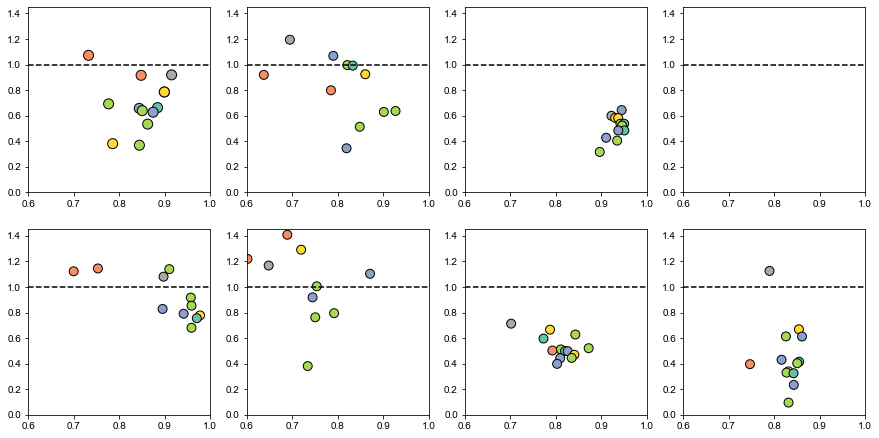

In [11]:
fig, ax = plt.subplots(2, 4, figsize=(15, 7.5))
ax = ax.flatten()

pdz_scores_df = model_classification_plot(all_scores, 'DLG4_HUMAN_Zarin_2024', x="AUC", ax=ax[0], ms=100)
amiE_scores_df = model_classification_plot(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', x="AUC", ax=ax[1])
pafa_scores_df = model_classification_plot(all_scores, 'ALPH_ELIME_Markin_2021', x="AUC", ax=ax[2])

trpB_scores_df = model_classification_plot(all_scores, 'TRPB1_PYRFU_Zhoufan_Li_2025', x="AUC", ax=ax[3], filter_to_subs=3)

ramR_scores_df = model_classification_plot(all_scores, 'HTHTR_SALTY_dOelsnitz_2025', x="AUC", ax=ax[5])
pho4_scores_df = model_classification_plot(all_scores, 'PHO4_YEAST_Aditham_2021', x="AUC", ax=ax[4])

norA_scores_df = model_classification_plot(all_scores, 'NORA_STAAU_Miller_2025', x="AUC", ax=ax[6])
nramp_scores_df = model_classification_plot(all_scores, 'MNTH_DEIRA_Berry_2025', x="AUC", ax=ax[7])

#plt.savefig('all_model_classifications.pdf', bbox_inches='tight', dpi=300)


In [12]:
all_aucs = pd.concat([pd.Series(df.AUC, name=protein) for protein,df in all_scores_dfs.items()], axis=1)
all_aucs['mean'] = all_aucs.mean(axis=1)

color_key = {'conservation': 'darkgray',
            'alignment_covariation':'#8da0cb',
                'plm':'#a6d854',
                'inverse_folding':'#fc8d62',
                'msa_plm':'#66c2a5',
                'structure_sequence':'#ffd92f'}


data = all_aucs.sort_values('mean', ascending=False).T

plt.figure(figsize=(8,4))
sns.swarmplot(data=data.drop('mean'), s=8,
              palette=[color_key[model_classification[x]] for x in data.columns],
              edgecolor='k', linewidth=0.5)

colors = [color_key[model_classification[x]] for x in data.columns]
for i in range(data.shape[1]):
    plt.plot([i-0.2, i+0.2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=2, zorder=10)

plt.xticks(rotation=90);
plt.ylim(0.5, 1)

#plt.savefig('that_plot.pdf', bbox_inches='tight', dpi=300)

NameError: name 'all_scores_dfs' is not defined

No model scores for PoET


AttributeError: 'numpy.ndarray' object has no attribute 'scatter'

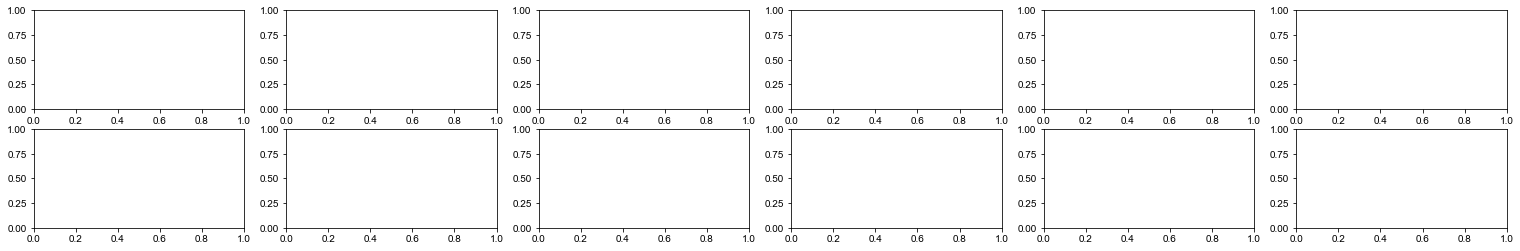

In [13]:
fig, ax = plt.subplots(2, 6, figsize=(22/5*6, 4))

pdz_scores_df = model_classification_plot(all_scores, 'DLG4_HUMAN_Zarin_2024', x="AUC", ax=ax[0], ms=80)
#amiE_scores_df = model_classification_plot(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', x="AUC", ax=ax[1], ms=80)
#pafa_scores_df = model_classification_plot(all_scores, 'ALPH_ELIME_Markin_2021', x="AUC", ax=ax[2])
#norA_scores_df = model_classification_plot(all_scores, 'NORA_STAAU_Miller_2025', x="AUC", ax=ax[-2])
nramp_scores_df = model_classification_plot(all_scores, 'MNTH_DEIRA_Berry_2025', x="AUC", ax=ax[1])
pafa_scores_df = model_classification_plot(all_scores, 'ALPH_ELIME_Markin_2021', x="AUC", ax=ax[2])
amiE_scores_df = model_classification_plot(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', x="AUC", ax=ax[3])
ramR_scores_df = model_classification_plot(all_scores, 'HTHTR_SALTY_dOelsnitz_2025', x="AUC", ax=ax[4])
pho4_scores_df = model_classification_plot(all_scores, 'PHO4_YEAST_Aditham_2021', x="AUC", ax=ax[5])

No model scores for PoET


AttributeError: 'numpy.ndarray' object has no attribute 'scatter'

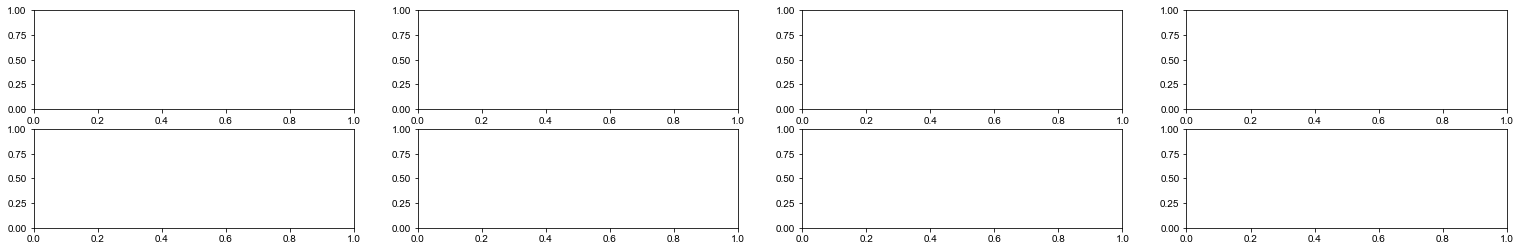

In [14]:
fig, ax = plt.subplots(2, 4, figsize=(22/5*6, 4))

pdz_scores_df = model_classification_plot(all_scores, 'DLG4_HUMAN_Zarin_2024', x="AUC", ax=ax[0])
amiE_scores_df = model_classification_plot(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', x="AUC", ax=ax[1])
pafa_scores_df = model_classification_plot(all_scores, 'ALPH_ELIME_Markin_2021', x="AUC", ax=ax[2])
norA_scores_df = model_classification_plot(all_scores, 'NORA_STAAU_Miller_2025', x="AUC", ax=ax[-2])
nramp_scores_df = model_classification_plot(all_scores, 'MNTH_DEIRA_Berry_2025', x="AUC", ax=ax[1])
pafa_scores_df = model_classification_plot(all_scores, 'ALPH_ELIME_Markin_2021', x="AUC", ax=ax[2])
amiE_scores_df = model_classification_plot(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', x="AUC", ax=ax[3])
ramR_scores_df = model_classification_plot(all_scores, 'HTHTR_SALTY_dOelsnitz_2025', x="AUC", ax=ax[4])
pho4_scores_df = model_classification_plot(all_scores, 'PHO4_YEAST_Aditham_2021', x="AUC", ax=ax[5])

In [ ]:
pho4_scores_df

,AUC,specificity_score,wt_spearman,color
model,,,,
ESM-IF1,0.753290,1.145088,-0.549804,"(0.984313725490196, 0.7058823529411765, 0.6823..."
Tranception_no_retrieval,0.910185,1.139755,-0.630175,lightgreen
ProteinMPNN,0.699954,1.122610,-0.409598,"(0.984313725490196, 0.7058823529411765, 0.6823..."
Site_independent,0.897544,1.080700,-0.737099,"(0.9490196078431372, 0.9490196078431372, 0.949..."
Progen2,0.957453,0.916991,-0.710099,lightgreen
ESM1v,0.958984,0.853852,-0.767675,lightgreen
EVmutation,0.895439,0.828251,-0.736603,lightblue
EVE,0.941680,0.790873,-0.772995,lightblue
SaProt_650M_AF2,0.977808,0.777639,-0.738720,"(0.8705882352941177, 0.796078431372549, 0.8941..."


In [15]:
all_scores['PHO4_YEAST_Aditham_2021']

,id,CCACGTGA,ACACGTGA,CCACGCGA,TCACGTGC,CACGTT,CATGTG,CAACGTG,GCACGTGC,CGCGTG,...,EVmutation,EVE,ESM1v,ESM2,Progen2,Tranception_no_retrieval,PoET,ProteinMPNN,ESM-IF1,SaProt_650M_AF2
mutant,,,,,,,,,,,,,,,,,,,,,
A245V,A245V,-0.069392,0.092109,NaN,0.155113,NaN,-0.045298,-0.081124,-0.203568,-0.229780,...,NaN,NaN,-0.240289,-0.103719,-0.008295,-0.001076,-807.65350,-2.641029,-2.564383,0.094902
A258L,A258L,0.955581,0.744510,0.351069,1.076170,0.387726,0.391706,0.320118,0.874877,0.216852,...,-6.448893,-4.815155,-4.414849,-11.947338,-0.008360,-0.005512,-812.83856,-2.646493,-2.558829,-7.958813
A258R,A258R,0.589342,0.141581,0.060626,-0.167256,0.024267,0.146176,0.073689,0.579713,-0.105153,...,-5.683399,-4.616135,-4.540157,-11.293718,-0.008376,-0.001383,-814.07135,-2.649008,-2.564118,-10.621337
A258V,A258V,1.453271,0.808339,0.381641,1.128721,0.581524,0.398602,0.447223,NaN,0.206804,...,-3.430794,-3.117584,-2.753063,-8.018317,-0.008345,-0.003127,-810.42957,-2.660296,-2.565704,-2.835553
A261V,A261V,0.564451,0.546489,0.062704,0.788752,0.010682,0.135803,0.127175,0.148633,-0.006822,...,-3.185837,-1.452621,-1.748373,-5.119302,-0.008341,-0.010691,-809.32947,-2.646804,-2.567253,-4.292407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W281V,W281V,0.592838,0.693943,0.179463,0.635041,0.212049,0.222031,0.288549,0.171349,0.217038,...,NaN,2.165237,0.783261,-1.748414,-0.008265,0.009005,-805.83570,-2.630038,-2.566436,-1.265438
WT,WT,-0.013719,-0.009884,0.005187,0.031400,-0.029700,0.014264,0.009767,-0.031717,-0.014645,...,0.000000,-0.045410,0.000000,0.000000,-0.008295,NaN,NaN,-2.643056,-2.559595,0.000000
Y302A,Y302A,2.261019,1.884044,0.869377,1.826248,1.098816,0.889282,0.983142,1.463029,0.862973,...,-5.755899,-6.787842,-4.786530,-10.127032,-0.008409,-0.014036,-813.56213,-2.650864,-2.576217,-9.663754


No model scores for GEMME
No model scores for MSA_Transformer
No model scores for PoET
No model scores for ESCOTT


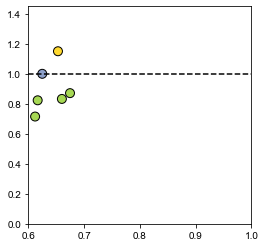

In [16]:
ramR_scores_df = model_classification_plot(all_scores, 'HTHTR_SALTY_dOelsnitz_2025', x="AUC", filter_to_subs=2)

In [17]:
norA_scores_df

,AUC,specificity_score,wt_spearman,color
model,,,,
Site_independent,0.701710,0.713090,0.381390,darkgray
SaProt_650M_AF2,0.787238,0.665930,0.531824,#ffd92f
Tranception_no_retrieval,0.842768,0.628314,0.618092,#a6d854
PoET,0.772786,0.596464,0.503014,#66c2a5
Progen2,0.872096,0.521112,0.662402,#a6d854
ESM2,0.810848,0.511523,0.564304,#a6d854
ESM-IF1,0.792324,0.503004,0.535495,#fc8d62
MSA_Transformer,0.820066,0.498958,0.579794,#66c2a5
GEMME,0.826109,0.497970,0.594794,#8da0cb


In [18]:
ramR_scores_df

,AUC,specificity_score,wt_spearman,color
model,,,,
ESM-IF1,0.602177,1.722575,0.197707,#fc8d62
SaProt_650M_AF2,0.653351,1.150680,0.297255,#ffd92f
EVmutation,0.625172,1.000236,0.235337,#8da0cb
ESM1v,0.674936,0.871338,0.314952,#a6d854
ESM2,0.660382,0.832674,0.280546,#a6d854
Progen2,0.616980,0.823544,0.218221,#a6d854
Tranception_no_retrieval,0.612377,0.715259,0.208168,#a6d854
EVE,0.818542,-0.273298,0.611326,#8da0cb
Site_independent,0.553700,NaN,0.104057,darkgray


In [19]:
nramp_scores_df

,AUC,specificity_score,wt_spearman,color
model,,,,
Site_independent,0.789695,1.125868,0.530537,darkgray
ESCOTT,0.854279,0.668961,0.653717,#ffd92f
ESM2,0.825723,0.613367,0.613017,#a6d854
GEMME,0.861122,0.612488,0.659687,#8da0cb
EVmutation,0.816132,0.430593,0.602103,#8da0cb
PoET,0.854864,0.415375,0.662814,#66c2a5
ESM1v,0.850604,0.403459,0.662655,#a6d854
ESM-IF1,0.746708,0.396240,0.469677,#fc8d62
SaProt_650M_AF2,0.831432,0.339950,0.635664,#ffd92f


No model scores for PoET


ValueError: x and y must be the same size

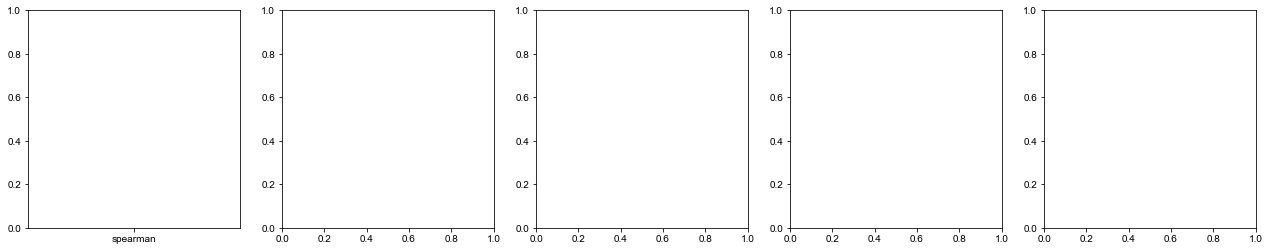

In [20]:
fig, ax = plt.subplots(1, 5, figsize=(22, 4))

pdz_scores_df = model_classification_plot(all_scores, 'DLG4_HUMAN_Zarin_2024', x="spearman", ax=ax[0], ms=80)
amiE_scores_df = model_classification_plot(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', x="spearman", ax=ax[1], ms=80)
pafa_scores_df = model_classification_plot(all_scores, 'ALPH_ELIME_Markin_2021', x="spearman", ax=ax[2])
norA_scores_df = model_classification_plot(all_scores, 'NORA_STAAU_Miller_2025', x="spearman", ax=ax[-2])
nramp_scores_df = model_classification_plot(all_scores, 'MNTH_DEIRA_Berry_2025', x="spearman", ax=ax[-1])

In [98]:
all_scores['TrpB_triples']

KeyError: 'TrpB_triples'

In [389]:
all_scores['TrpB_triples'] = all_scores['TRPB1_PYRFU_Zhoufan_Li_2025'][all_scores['TRPB1_PYRFU_Zhoufan_Li_2025'].n_subs==3]

In [390]:
all_scores['TrpB_triples']

,variant,fitness_7bromo,fitness_7iodo,fitness_7methyl,fitness_5bromo,fitness_5chloro,fitness_5iodo,fitness_4bromo,fitness_6chloro,fitness_5cyano,...,EVmutation,EVE,ESM1v,ESM2,Progen2,Tranception_no_retrieval,MSA_Transformer,PoET,ESM-IF1,SaProt_650M_AF2
mutant,,,,,,,,,,,,,,,,,,,,,
I165A:I183G:Y301C,"I165A,I183G,Y301C",0.089829,0.062420,0.539895,0.044171,0.096129,0.077053,0.005751,0.026162,0.032572,...,NaN,-25.199707,-23.132830,-20.352152,-0.002392,-0.084724,-21.384686,-583.72910,-6.836094,1.793115
I165A:I183V:Y301H,"I165A,I183V,Y301H",0.719840,0.456760,1.029422,0.232102,0.272495,1.691888,0.033192,0.648992,0.020472,...,NaN,-18.708191,-14.133358,-11.501050,-0.002282,-0.054433,-14.077647,-578.70670,-6.830425,0.943577
I165A:I183V:Y301M,"I165A,I183V,Y301M",0.551260,0.396256,0.911466,0.097865,0.132310,0.246331,0.480829,0.199852,0.023234,...,NaN,-21.936096,-17.371834,-15.043822,-0.002320,-0.055894,-16.707374,-579.73270,-6.832556,0.559773
I165C:I183C:Y301E,"I165C,I183C,Y301E",0.281215,0.083216,0.226820,0.027176,0.101875,0.463804,0.012057,0.174412,0.007628,...,NaN,-23.953369,-22.228781,-22.341691,-0.002387,-0.076426,-22.728334,-584.97516,-6.833743,-0.545550
I165C:I183D:Y301P,"I165C,I183D,Y301P",0.061530,-0.039008,0.017380,0.002135,-0.007094,-0.045815,0.003188,-0.028567,0.001227,...,NaN,-24.929077,-28.686210,-28.127359,-0.002454,-0.099609,-26.557310,-587.72375,-6.868109,1.031378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
I165Y:I183S:Y301M,"I165Y,I183S,Y301M",NaN,0.530506,0.674653,0.055844,0.164275,0.099287,0.042174,0.181225,0.035587,...,NaN,-29.429443,-28.712164,-24.562901,-0.002417,-0.077300,-24.875291,-583.34430,-6.823982,0.908272
I165Y:I183T:Y301G,"I165Y,I183T,Y301G",NaN,0.155388,0.412734,0.148282,0.122835,0.256070,0.042463,0.158576,-0.003375,...,NaN,-27.396484,-27.862782,-23.538308,-0.002427,-0.092112,-24.649341,-583.78050,-6.833504,3.225435
I165Y:I183T:Y301M,"I165Y,I183T,Y301M",NaN,0.847321,0.875587,0.161199,0.221641,0.074638,0.142579,0.470452,-0.024867,...,NaN,-28.070740,-26.350610,-22.384004,-0.002398,-0.071898,-22.752132,-582.30444,-6.828380,0.542999


In [33]:
pdz_scores_df

,AUC,specificity_score,wt_spearman,color
model,,,,
ProteinMPNN,0.732681,1.072582,0.217703,#fc8d62
Site_independent,0.915229,0.919676,0.426306,darkgray
ESM-IF1,0.848227,0.916132,0.332407,#fc8d62
Progen2,0.776732,0.692888,0.378584,#a6d854
MSA_Transformer,0.884358,0.663624,0.578161,#66c2a5
EVE,0.844098,0.657916,0.565923,#8da0cb
Tranception_no_retrieval,0.850799,0.639727,0.445366,#a6d854
EVmutation,0.874634,0.627613,0.528122,#8da0cb
ESM2,0.862639,0.534521,0.544479,#a6d854


In [21]:
all_scores_dfs = {'pdz':pdz_scores_df, 'amiE':amiE_scores_df, 'pafa':pafa_scores_df, 'pho4':pho4_scores_df, 'ramR':ramR_scores_df, 'norA':norA_scores_df, 'nramp':nramp_scores_df}
all_specificity_scores = pd.concat([pd.Series(df.specificity_score, name=protein) for protein,df in all_scores_dfs.items()], axis=1).drop("ProteinMPNN")
all_specificity_scores['mean'] = all_specificity_scores.mean(axis=1)

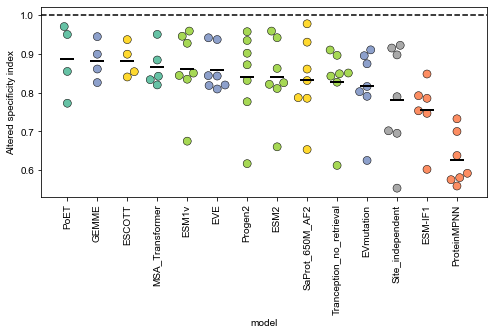

In [24]:
color_key = {'conservation': 'darkgray',
            'alignment_covariation':'#8da0cb',
                'plm':'#a6d854',
                'inverse_folding':'#fc8d62',
                'msa_plm':'#66c2a5',
                'structure_sequence':'#ffd92f'}

all_aucs = pd.concat([pd.Series(df.AUC, name=protein) for protein,df in all_scores_dfs.items()], axis=1)
all_aucs['mean'] = all_aucs.mean(axis=1)

data = all_aucs.sort_values('mean', ascending=False).T

plt.figure(figsize=(8,3.5))
sns.swarmplot(data=data.drop('mean'), s=8,
              palette=[color_key[model_classification[x]] for x in data.columns],
              edgecolor='k', linewidth=0.5)
plt.axhline(1, c='k', ls='dashed')

colors = [color_key[model_classification[x]] for x in data.columns]
for i in range(data.shape[1]):
    plt.plot([i-0.2, i+0.2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=2, zorder=10)

plt.xticks(rotation=90);
plt.ylabel("Altered specificity index")

plt.savefig('AUC_plot.pdf', bbox_inches='tight', dpi=300)

In [112]:
all_aucs

,pdz,amiE,pafa,norA,nramp,mean
model,,,,,,
ProteinMPNN,0.732681,0.637941,0.592048,0.580862,0.559202,0.620547
ESM-IF1,0.848227,0.785497,NaN,0.792324,0.746708,0.793189
Progen2,0.776732,0.901809,0.934728,0.872096,0.831461,0.863365
MSA_Transformer,0.884358,0.833570,0.950476,0.820066,0.842501,0.866194
EVE,0.843960,0.819859,0.937215,0.809480,0.843009,0.850705
Tranception_no_retrieval,0.850799,0.848851,0.896440,0.842768,0.827055,0.853183
EVmutation,0.874634,0.790693,0.910538,0.802719,0.816019,0.838921
ESM2,0.862639,0.821588,0.941959,0.810848,0.825723,0.852551
SaProt_650M_AF2,0.785655,0.860981,0.930406,0.787238,0.831432,0.839142


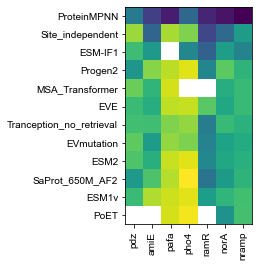

In [17]:
plt.imshow(all_aucs.drop('mean', axis=1),);
plt.xticks(range(len(all_aucs.columns[:-1])), all_aucs.columns[:-1], rotation=90);
plt.yticks(range(len(all_aucs.index)), all_aucs.index);

Text(65.0, 0.5, 'Altered specificity index')

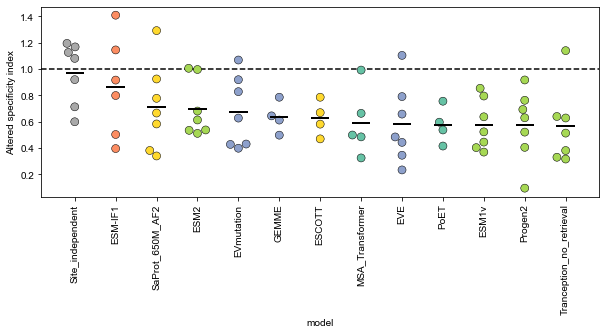

In [48]:
color_key = {'conservation': 'darkgray',
            'alignment_covariation':'#8da0cb',
                'plm':'#a6d854',
                'inverse_folding':'#fc8d62',
                'msa_plm':'#66c2a5',
                'structure_sequence':'#ffd92f'}

data = all_specificity_scores.sort_values('mean', ascending=False).T

plt.figure(figsize=(10,3.5))
sns.swarmplot(data=data.drop('mean'), s=8,
              palette=[color_key[model_classification[x]] for x in data.columns],
              edgecolor='k', linewidth=0.5)
plt.axhline(1, c='k', ls='dashed')

colors = [color_key[model_classification[x]] for x in data.columns]
for i in range(data.shape[1]):
    plt.plot([i-0.2, i+0.2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=2, zorder=10)

plt.xticks(rotation=90);
plt.ylabel("Altered specificity index")

#plt.savefig('ASI_plot.pdf', bbox_inches='tight', dpi=300)

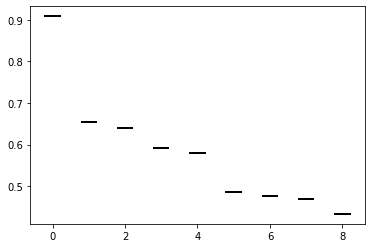

In [ ]:
for i in range(data.shape[1]):
#data.loc['mean']

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Site_independent'),
  Text(1, 0, 'ESM-IF1'),
  Text(2, 0, 'ESM2'),
  Text(3, 0, 'MSA_Transformer'),
  Text(4, 0, 'EVmutation'),
  Text(5, 0, 'SaProt_650M_AF2'),
  Text(6, 0, 'PoET'),
  Text(7, 0, 'Tranception_no_retrieval'),
  Text(8, 0, 'ESM1v'),
  Text(9, 0, 'Progen2'),
  Text(10, 0, 'EVE')])

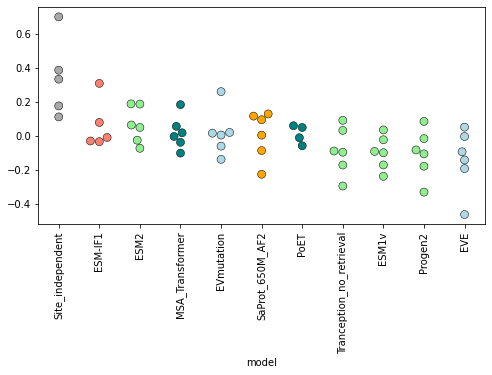

In [127]:
color_key = {'conservation': 'darkgray',
            'alignment_covariation':'lightblue',
                'plm':'lightgreen',
                'inverse_folding':'salmon',
                'msa_plm':'teal',
                'structure_sequence':'orange'}

x2 = all_specificity_scores - all_specificity_scores.mean(axis=0)

data = all_specificity_scores.sort_values('mean', ascending=False).T

plt.figure(figsize=(8,4))
sns.swarmplot(data=x2.sort_values('mean', ascending=False).T, s=8,
              palette=[color_key[model_classification[x]] for x in data.columns],
              edgecolor='k', linewidth=0.5)
#plt.axhline(1, c='k', ls='dashed')

plt.xticks(rotation=90)

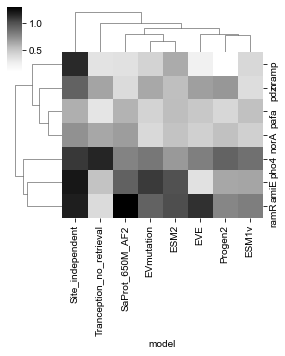

In [51]:
sns.clustermap(all_specificity_scores.dropna().drop('mean', axis=1).T, cmap='Greys', figsize=(4,5))

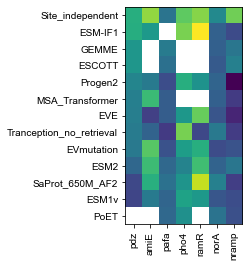

In [52]:
plt.imshow(all_specificity_scores.drop('mean', axis=1),);
plt.xticks(range(len(all_specificity_scores.columns[:-1])), all_specificity_scores.columns[:-1], rotation=90);
plt.yticks(range(len(all_specificity_scores.index)), all_specificity_scores.index);

In [139]:
len([color_key[model_classification[x]] for x in data.columns])

9

In [106]:
nramp_scores_df

,AUC,specificity_score,wt_spearman,color
model,,,,
ProteinMPNN,0.559202,2.145052,0.100239,"(0.984313725490196, 0.7058823529411765, 0.6823..."
Site_independent,0.789570,1.126436,0.530291,"(0.9490196078431372, 0.9490196078431372, 0.949..."
ESM2,0.825723,0.613367,0.613017,lightgreen
EVmutation,0.816019,0.431107,0.601880,"(0.7019607843137254, 0.803921568627451, 0.8901..."
ESM1v,0.850604,0.403459,0.662655,lightgreen
ESM-IF1,0.746708,0.396240,0.469677,"(0.984313725490196, 0.7058823529411765, 0.6823..."
SaProt_650M_AF2,0.831432,0.339950,0.635664,"(0.8705882352941177, 0.796078431372549, 0.8941..."
Tranception_no_retrieval,0.827055,0.330220,0.624398,lightgreen
EVE,0.843009,0.233950,0.644873,"(0.996078431372549, 0.8509803921568627, 0.6509..."


# Precision plots

In [255]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

def define_prediction_task(df, model_names):
    
    data = df.copy()
    data['hit'] = data['specificity_category']=='altered-specificity'
    return data[model_names + ['hit']].dropna()

def precision_recall_analysis(df, model_name):
    data = df.copy()
    if 'hit' not in data.columns:
        data['hit'] = data['specificity_category']=='altered-specificity'
    
    random_hit_rate = data['hit'].mean()

    data = data[['hit', model_name]].dropna()
    ap = average_precision_score(data['hit'], data[model_name])
    naPS = ap - random_hit_rate

    precision, recall, thresholds = precision_recall_curve(data['hit'], data[model_name])
    
    prc_df = pd.DataFrame([precision, recall, thresholds]).T.rename(columns={0:'precision', 1:'recall', 2:'thresholds'})
    prc_df = prc_df.loc[prc_df.recall>0]
    
    return prc_df, ap, naPS, random_hit_rate

In [216]:
all_tasks = [define_prediction_task(all_scores[k], ['Site_independent', 'ESM1v']) for k in all_scores.keys()]

In [301]:
norA_prediction_task = define_prediction_task(selector(all_scores['NORA_STAAU_Miller_2025'], {"n_subs":1}), ['Site_independent', 'ESM1v'])

In [230]:
from sklearn.linear_model import LogisticRegression

In [232]:
nramp_prediction_task.values[:,2]

array([False, False, False, ..., False, False, False], dtype=object)

In [234]:
lr = LogisticRegression()
lr.fit(nramp_prediction_task.values[:,:2], nramp_prediction_task.values[:,2].astype(int))

LogisticRegression()

In [293]:
nramp_prediction_task['simple_diff'] = 0.50532525 * nramp_prediction_task['Site_independent'] - 0.38287816 * nramp_prediction_task['ESM1v']

In [263]:
lr_pred = pd.Series(lr.predict_log_proba(nramp_prediction_task.values[:,:2])[:,1], index=nramp_prediction_task.index, name='logit_score')
Nramp_predictions = pd.concat([lr_pred, nramp_prediction_task['hit']], axis=1).sort_values('logit_score', ascending=False)

In [ ]:
(lr.coef_ * nramp_prediction_task.values[:,:2] + lr.intercept_)

array([[-7.1196444332684, -4.8773627844437835],
       [-9.09971594237054, -3.8616005734151044],
       [-6.435278599389819, -5.877374288777318],
       ...,
       [-6.505907027646723, -5.499542317685582],
       [-6.7146796442549705, -5.759453241779192],
       [-7.404858439718174, -5.2753903335356345]], dtype=object)

In [299]:
nramp_prediction_task.values[:,:2]

array([[-1.9398376789899885, -3.2961731433868406],
       [-5.85824770586305, -5.949137783050537],
       [-0.5855300526279734, -0.6843461513519287],
       ...,
       [-0.725298308568199, -1.6711665391921997],
       [-1.138443344236748, -0.9923319816589355],
       [-2.5042543768415726, -2.2566060066223144]], dtype=object)

In [270]:
pd.concat([lr_pred, nramp_prediction_task['hit']], axis=1).loc['A85D']

logit_score   -2.972861
hit                True
Name: A85D, dtype: object

In [266]:
precision_recall_analysis(Nramp_predictions, 'logit_score')[0]

,precision,recall,thresholds
0,0.019074,1.000000,-5.335648
1,0.017735,0.928571,-5.333304
2,0.017760,0.928571,-5.332261
3,0.017784,0.928571,-5.332023
4,0.017808,0.928571,-5.330401
...,...,...,...
712,0.045455,0.071429,-2.875661
713,0.047619,0.071429,-2.863147
714,0.050000,0.071429,-2.803100
715,0.052632,0.071429,-2.798809


In [316]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Example: your DataFrame
# df has columns: 'score1', 'score2', 'label'
X = norA_prediction_task[['Site_independent', 'ESM1v']].values
y = norA_prediction_task['hit'].values

# Optional: split into train/test (you said you already have a test set)
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Scale features — important if score1 and score2 are on different scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Fit logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Inspect learned weights
coef = model.coef_[0]
intercept = model.intercept_[0]
print(f"Intercept: {intercept:.3f}")
print(f"Weights: score1={coef[0]:.3f}, score2={coef[1]:.3f}")
print(f"Relative weighting (score1 / -score2): {coef[0] / -coef[1]:.3f}")

# Evaluate on validation or test set
from sklearn.metrics import roc_auc_score
preds = model.predict_proba(X_val_scaled)[:, 1]
print("Validation AUC:", roc_auc_score(y_val, preds))
print("Validation naPS:", average_precision_score(y_val, preds) / y_val.mean())

Intercept: -2.788
Weights: score1=0.311, score2=-0.374
Relative weighting (score1 / -score2): 0.830
Validation AUC: 0.633426041735238
Validation naPS: 1.5336787253074473


In [313]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

nramp_prediction_task = define_prediction_task(selector(all_scores['MNTH_DEIRA_Berry_2025'], {"n_subs":1}), ['Site_independent', 'Progen2'])

# Example: your DataFrame
# df has columns: 'score1', 'score2', 'label'
X = nramp_prediction_task[['Site_independent', 'Progen2']].values
y = nramp_prediction_task['hit'].values

# Optional: split into train/test (you said you already have a test set)
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Scale features — important if score1 and score2 are on different scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Fit logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Inspect learned weights
coef = model.coef_[0]
intercept = model.intercept_[0]
print(f"Intercept: {intercept:.3f}")
print(f"Weights: score1={coef[0]:.3f}, score2={coef[1]:.3f}")
print(f"Relative weighting (score1 / -score2): {coef[0] / -coef[1]:.3f}")

# Evaluate on validation or test set
from sklearn.metrics import roc_auc_score
preds = model.predict_proba(X_val_scaled)[:, 1]
print("Validation AUC:", roc_auc_score(y_val, preds))
print("Validation naPS:", average_precision_score(y_val, preds) / y_val.mean())

Intercept: -5.212
Weights: score1=0.763, score2=-0.712
Relative weighting (score1 / -score2): 1.072
Validation AUC: 0.8627450980392156
Validation naPS: 5.08310302783987


Optimal alpha = 5.000


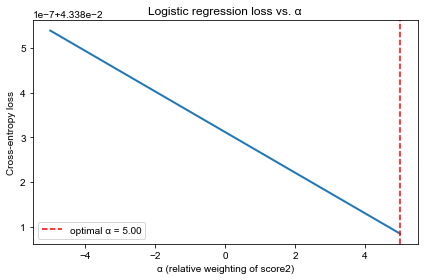

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# Example: df has columns 'score1', 'score2', 'label'

df = nramp_prediction_task.copy()

s1 = df['Site_independent'].values
s2 = df['Progen2'].values
y = df['hit'].values

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

# df: columns 'score1', 'score2', 'label'
y = df['label'].values

# 1) Standardize each score ONCE (no label info needed beyond fitting scalers)
sc1 = StandardScaler().fit(df[['score1']])
sc2 = StandardScaler().fit(df[['score2']])
z1 = sc1.transform(df[['score1']]).ravel()
z2 = sc2.transform(df[['score2']]).ravel()

def neg_log_loss_fixed(z1, z2, y, alpha):
    x = (z1 - alpha * z2).reshape(-1, 1)  # no per-α standardization
    # 2) No regularization (or set C very large if 'none' not available)
    model = LogisticRegression(penalty='none', solver='lbfgs', max_iter=2000)
    model.fit(x, y)
    p = model.predict_proba(x)[:, 1]
    return log_loss(y, p)

# 3) Grid search α; widen range if needed
alphas = np.linspace(-5, 5, 401)  # 0.025 steps
losses = [neg_log_loss_fixed(z1, z2, y, a) for a in alphas]
alpha_opt = alphas[int(np.argmin(losses))]
alpha_opt

In [319]:
y

array([False, False, False, ..., False, False, False])

In [307]:
average_precision_score(y_val, preds) - y_val.mean()

0.03196986237376131

In [306]:
y_val.mean()

0.059904697072838665

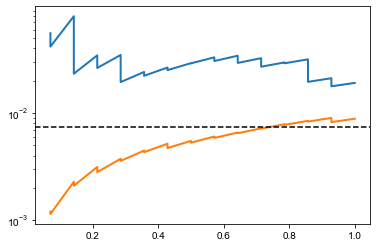

In [295]:
res= precision_recall_analysis(nramp_prediction_task, 'simple_diff')
res2 = precision_recall_analysis(nramp_prediction_task, 'ESM1v')

plt.plot(res[0]['recall'], res[0]['precision'], label='simple diff', lw=2)
plt.plot(res2[0]['recall'], res2[0]['precision'], label='ESM1v', lw=2)
plt.axhline(res[-1], ls='--', c='k')
plt.yscale('log')

In [334]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from scipy.optimize import minimize_scalar

X = nramp_prediction_task[['Site_independent', 'Progen2']].values
y = nramp_prediction_task['hit'].values

# Example: df has columns 'score1', 'score2', 'label'
s1 = X[:,0]
s2 = X[:,1]

def neg_log_loss(alpha):
    """Compute negative log loss for given alpha."""
    combined = s1 - alpha * s2
    model = LogisticRegression()
    model.fit(combined.reshape(-1, 1), y)
    probs = model.predict_proba(combined.reshape(-1, 1))[:, 1]
    return log_loss(y, probs)

# Search for optimal alpha
res = minimize_scalar(neg_log_loss, bounds=(-10, 10), method='bounded')
alpha_opt = res.x
print(f"Optimal alpha = {alpha_opt:.3f}")

# Fit final logistic on combined score with that alpha
combined = (s1 - alpha_opt * s2)
#combined = (combined - combined.mean()) / combined.std()
final_model = LogisticRegression()
final_model.fit(combined.reshape(-1, 1), y)

print("Intercept:", final_model.intercept_[0])
print("Slope:", final_model.coef_[0][0])

Optimal alpha = 10.000
Intercept: -4.580699580909494
Slope: 0.11493592125324135


In [330]:
combined

array([-1.92653453, -5.84464168, -0.57222133, ..., -0.71203135,
       -1.12524402, -2.49100828])

In [332]:
average_precision_score(y, combined) / y.mean()

1.163320646023134

In [251]:
lr_pred.sort_values(ascending=True).iloc[:20]

mutant
R244W   -9.310520
T62P    -9.078168
S326E   -9.076341
A61P    -9.027203
V192E   -8.842757
Q193H   -8.792951
G45W    -8.476724
G100W   -8.463337
C382D   -8.448417
M268D   -8.436782
M55G    -8.296036
I49P    -8.294040
S326R   -8.198183
I49Q    -8.161835
L374E   -8.143941
L374Y   -8.113122
N275E   -8.093296
I49N    -8.079124
G100V   -8.065167
S51D    -8.048304
Name: logit_score, dtype: float64

In [229]:
nramp_prediction_task.values[:,:3]

array([[-1.9398376789899885, -3.2961731433868406, False],
       [-5.85824770586305, -5.949137783050537, False],
       [-0.5855300526279734, -0.6843461513519287, False],
       ...,
       [-0.725298308568199, -1.6711665391921997, False],
       [-1.138443344236748, -0.9923319816589355, False],
       [-2.5042543768415726, -2.2566060066223144, False]], dtype=object)

In [201]:
prc_df, ap, nAPS, random_hit_rate = precision_recall_analysis(all_scores['MNTH_DEIRA_Berry_2025'], 'Site_independent')

(0.0, 1.0)

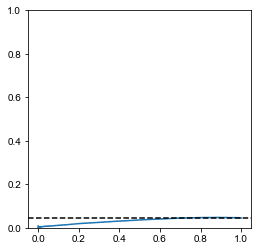

In [207]:
plt.figure(figsize=(4,4))
plt.plot(prc_df.recall, prc_df.precision)
plt.axhline(random_hit_rate, c='k', ls='dashed')
plt.ylim(0,1)

In [171]:
data[['hit', 'ESM1v']].sort_values('ESM1v')

,hit,ESM1v
mutant,,
I39W,False,-17.488757
N24W,True,-17.067251
V60W,False,-16.638019
I25W,False,-16.439054
F23E,False,-16.248866
...,...,...
S69T,False,2.669796
I75T,False,2.959380
K91R,False,3.315314


(0.0, 1.0)

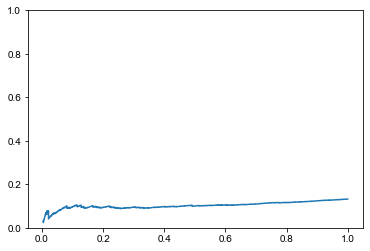

In [176]:
plt.plot(recall[recall>0], precision[recall>0])
plt.ylim(0,1)

In [162]:
help(precision_recall_curve)

Help on function precision_recall_curve in module sklearn.metrics._ranking:

precision_recall_curve(y_true, probas_pred, *, pos_label=None, sample_weight=None)
    Compute precision-recall pairs for different probability thresholds.
    
    Note: this implementation is restricted to the binary classification task.
    
    The precision is the ratio ``tp / (tp + fp)`` where ``tp`` is the number of
    true positives and ``fp`` the number of false positives. The precision is
    intuitively the ability of the classifier not to label as positive a sample
    that is negative.
    
    The recall is the ratio ``tp / (tp + fn)`` where ``tp`` is the number of
    true positives and ``fn`` the number of false negatives. The recall is
    intuitively the ability of the classifier to find all the positive samples.
    
    The last precision and recall values are 1. and 0. respectively and do not
    have a corresponding threshold. This ensures that the graph starts on the
    y axis.
    
  

In [153]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

precision_scores = []
roc_auc_scores = []

all_spec_predictors

for spec_predictor in all_spec_predictors:
    
    nd = new_data[['category', 'spec_change', spec_predictor]].dropna()
    
    precision_score = average_precision_score(nd.category=="spec_change", nd[spec_predictor])
    precision_scores.append([spec_predictor, precision_score])

NameError: name 'all_spec_predictors' is not defined

# Design plots

In [227]:
data

model,Site_independent,ESM-IF1,ESM2,MSA_Transformer,EVmutation,SaProt_650M_AF2,PoET,Tranception_no_retrieval,ESM1v,Progen2,EVE
pdz,NaN,0.916132,0.534521,0.663624,0.627613,0.381601,NaN,0.639727,0.369434,0.692888,0.658712
amiE,1.194669,0.798924,0.996501,0.992143,1.068472,0.924571,NaN,0.513522,0.637310,0.629862,0.345503
pafa,0.599642,NaN,0.537477,0.484880,0.427634,0.583018,0.537424,0.316633,0.523079,0.405289,0.484336
norA,0.713090,0.503004,0.511523,0.498958,0.398667,0.665930,0.596464,0.628314,0.445339,0.521112,0.443202
nramp,1.126436,0.396240,0.613367,0.325029,0.431107,0.339950,0.415375,0.330220,0.403459,0.095562,0.233950
mean,0.908459,0.653575,0.638678,0.592927,0.590699,0.579014,0.516421,0.485683,0.475724,0.468942,0.433140


1232


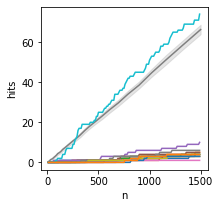

In [229]:
specificity_design_plot(all_scores['MNTH_DEIRA_Berry_2025'], 
                        models=model_names, 
                        func=lambda x: np.sum(x.specificity_category=="altered-specificity"))

In [231]:
all_scores['MNTH_DEIRA_Berry_2025']['n_subs']==2

mutant
A129S                False
A133S:M230A           True
A138D                False
A138S                False
A139S                False
                     ...  
T228S:M230V           True
V222I:I234R           True
V222S:M230A:S377C    False
WT                   False
wt                   False
Name: n_subs, Length: 27537, dtype: bool

In [248]:
nramp_data = all_scores['MNTH_DEIRA_Berry_2025'].copy()
nramp_data['Mg_specific'] = (nramp_data.Mg_import_score > 2) & ((nramp_data.Mn_import_score<0.15) & (nramp_data.specificity_category == 'altered-specificity'))

In [274]:
def specificity_design_plot(data, func, models, figsize=(3,3), baseline_reps=50, xmax=1500):

    plt.figure(figsize=figsize)

    y = []
    for i in range(baseline_reps):
        x = data.iloc[np.random.choice(np.arange(len(data)), len(data), replace=False)]
        
        for i in np.logspace(1, np.log10(xmax), 40):
        
            y.append([i, func(x[:int(i)])])

    y_df = pd.DataFrame(y, columns=['n', 'hits'])
    sns.lineplot(data=y_df, x="n", y="hits", c='gray')
    
    for model in models:
        x = data.sort_values(model, ascending=False)
        y = []
        for i in np.arange(10, xmax, 10):
            y.append(func(x[:i]))
        
        plt.plot(np.arange(10, xmax, 10), np.array(y), label=model)

    total_ = np.sum(func(x))
    print(total_)

209


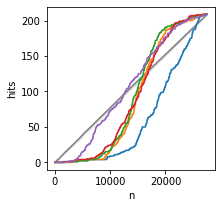

In [275]:
specificity_design_plot(nramp_data, 
                        models=['Site_independent', 'EVmutation', 'EVE', 'ESM1v', 'ESM-IF1'], 
                        func=lambda x: np.sum(x.Mg_specific==True), xmax=27500)

In [299]:
nramp_data.loc[:,'EVE_diff'] = nramp_data['Site_independent'] - 2*nramp_data['EVE']
nramp_data.loc[:,'ESM_diff'] = nramp_data['Site_independent'] - 2*nramp_data['ESM1v']

In [314]:
list(models)

['Site_independent',
 'EVmutation',
 'EVE',
 'ESM1v',
 'ESM2',
 'Progen2',
 'Tranception_no_retrieval',
 'MSA_Transformer',
 'PoET',
 'ProteinMPNN',
 'ESM-IF1',
 'SaProt_650M_AF2']

In [319]:
Q = nramp_data.groupby('n_subs').mean(['Mn_import_score', 'Mg_import_score'] + list(models))[['Mn_import_score', 'Mg_import_score'] + list(models)].dropna()

<Axes: xlabel='n_subs', ylabel='Mn_import_score'>

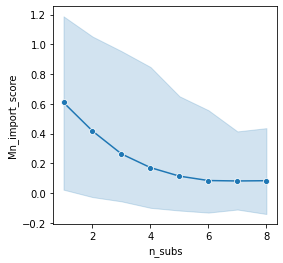

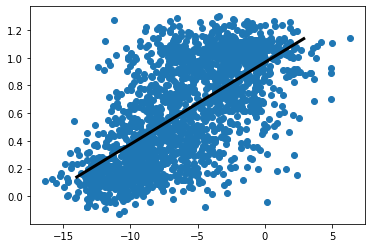

In [359]:
from scipy.stats import linregress

df = nramp_data.loc[nramp_data.n_subs<9][['n_subs', 'ESM1v', 'Mn_import_score']].dropna()
m, b, _, _, _ = linregress(df.loc[df.n_subs==1]['ESM1v'],
            df.loc[df.n_subs==1]['Mn_import_score'])

plt.scatter(df.loc[df.n_subs==1]['ESM1v'],
            df.loc[df.n_subs==1]['Mn_import_score'])

x = np.arange(-14,3,0.1)
plt.plot(x, m*x+b, c='k', lw=3)

<Axes: xlabel='n_subs', ylabel='ESM1v_rescaled'>

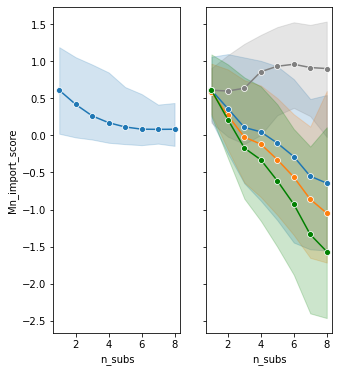

In [381]:
fig, axs = plt.subplots(1,2, figsize=(5,6), sharey=True, sharex=True)
sns.lineplot(data=nramp_data.loc[nramp_data.n_subs<9], x="n_subs", y="Mn_import_score", errorbar='pi', marker='o', ax=axs[0])

df = nramp_data.loc[nramp_data.n_subs<9][['n_subs', 'ESM1v', 'Mn_import_score']].dropna()
m_esm, b_esm, _, _, _ = linregress(df.loc[df.n_subs==1]['ESM1v'],
            df.loc[df.n_subs==1]['Mn_import_score'])

df.loc[:,'ESM1v_rescaled'] = df['ESM1v']*m_esm + b_esm

sns.lineplot(data=df, x="n_subs", y="ESM1v_rescaled", errorbar='pi', marker='o', ax=axs[1])

m_esm, b_esm, _, _, _ = linregress(df.loc[df.n_subs==1]['ESM1v'],
            df.loc[df.n_subs==1]['Mn_import_score'])

df = nramp_data.loc[nramp_data.n_subs<9][['n_subs', 'EVmutation', 'Mn_import_score']].dropna()
df.loc[:,'EVmutation_rescaled'] = df['EVmutation']*m_esm + b_esm

sns.lineplot(data=df, x="n_subs", y="EVmutation_rescaled", errorbar='pi', marker='o', ax=axs[1])

df = nramp_data.loc[nramp_data.n_subs<9][['n_subs', 'Site_independent', 'Mn_import_score']].dropna()
m_esm, b_esm, _, _, _ = linregress(df.loc[df.n_subs==1]['Site_independent'],
            df.loc[df.n_subs==1]['Mn_import_score'])

df = nramp_data.loc[nramp_data.n_subs<9][['n_subs', 'Site_independent', 'Mn_import_score']].dropna()
df.loc[:,'Site_independent_rescaled'] = df['Site_independent']*m_esm + b_esm

sns.lineplot(data=df, x="n_subs", y="Site_independent_rescaled", errorbar='pi', marker='o', ax=axs[1], c='gray')

df = nramp_data.loc[nramp_data.n_subs<9][['n_subs', 'EVE', 'Mn_import_score']].dropna()
m_esm, b_esm, _, _, _ = linregress(df.loc[df.n_subs==1]['EVE'],
            df.loc[df.n_subs==1]['Mn_import_score'])

df = nramp_data.loc[nramp_data.n_subs<9][['n_subs', 'EVE', 'Mn_import_score']].dropna()
df.loc[:,'EVE_rescaled'] = df['EVE']*m_esm + b_esm

sns.lineplot(data=df, x="n_subs", y="EVE_rescaled", errorbar='pi', marker='o', ax=axs[1], c='green')

In [355]:
m

nan

<Axes: xlabel='n_subs', ylabel='ESM1v'>

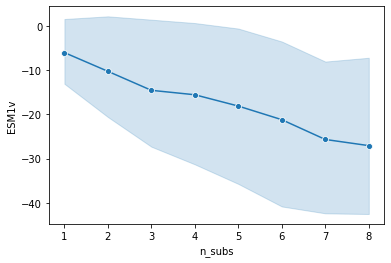

In [336]:
sns.lineplot(data=nramp_data.loc[nramp_data.n_subs<9], x="n_subs", y="ESM1v", errorbar='pi', marker='o')

In [329]:
help(sns.lineplot)

Help on function lineplot in module seaborn.relational:

lineplot(data=None, *, x=None, y=None, hue=None, size=None, style=None, units=None, weights=None, palette=None, hue_order=None, hue_norm=None, sizes=None, size_order=None, size_norm=None, dashes=True, markers=None, style_order=None, estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, orient='x', sort=True, err_style='band', err_kws=None, legend='auto', ci='deprecated', ax=None, **kwargs)
    Draw a line plot with possibility of several semantic groupings.
    
    The relationship between `x` and `y` can be shown for different subsets
    of the data using the `hue`, `size`, and `style` parameters. These
    parameters control what visual semantics are used to identify the different
    subsets. It is possible to show up to three dimensions independently by
    using all three semantic types, but this style of plot can be hard to
    interpret and is often ineffective. Using redundant semantics (i.e. both
    `hue` and

172


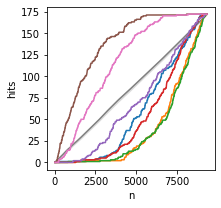

In [302]:
specificity_design_plot(nramp_data.loc[nramp_data.n_subs==2], 
                        models=['Site_independent', 'EVmutation', 'EVE', 'ESM1v', 'ESM-IF1', 'EVE_diff', 'ESM_diff'], 
                        func=lambda x: np.sum(x.Mg_specific==True), xmax=len(nramp_data.loc[nramp_data.n_subs==2]))

#plt.xscale('log'); plt.yscale('log')

209


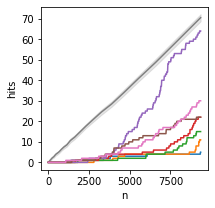

In [304]:
specificity_design_plot(nramp_data, 
                        models=['Site_independent', 'EVmutation', 'EVE', 'ESM1v', 'ESM-IF1', 'EVE_diff', 'ESM_diff'], 
                        func=lambda x: np.sum(x.Mg_specific==True), xmax=len(nramp_data.loc[nramp_data.n_subs==2]))

#plt.xscale('log'); plt.yscale('log')

In [ ]:
plt.figure(figsize=(3,3))

data = nramp_data

y = []
for i in range(10):
    x = data.iloc[np.random.choice(np.arange(len(data)), len(data), replace=False)]
    
    for i in np.logspace(1, np.log10(1887), 40):
    
        y.append([i, func(x[:int(i)])])

y_df = pd.DataFrame(y, columns=['n', 'hits'])
sns.lineplot(data=y_df, x="n", y="hits", c='gray')

for model in models:
    x = data.sort_values(model, ascending=False)
    y = []
    for i in np.arange(10, xmax, 10):
        y.append(func(x[:i]))
    
    plt.plot(np.arange(10, xmax, 10), np.array(y), label=model)

total_ = np.sum(func(x))
print(total_)

NameError: name 'func' is not defined

<Figure size 216x216 with 0 Axes>

In [272]:
x

,variant,Mn_import_score,Mn_import_score_err,Mg_import_score,Mg_import_score_err,n_reads_l1,n_reads_l2,aa_seq,n_subs,specificity_category,...,ESM1v,ESM2,Progen2,Tranception_no_retrieval,MSA_Transformer,PoET,ProteinMPNN,ESM-IF1,SaProt_650M_AF2,Mg_specific
mutant,,,,,,,,,,,,,,,,,,,,,
R255L:G272H,"R255L,G272H",1.051698,0.081212,NaN,NaN,0.0,20.0,MDSRSPSLPDDRPDPPEQHLDARAGATLRGTAGPRGVRRILPFLGP...,2.0,native-specificity,...,-12.241386,-10.584485,-0.002755,-0.041341,-16.191460,-689.94525,-1.999734,-1.110816,-12.339974,False
D56G:T172Y:L365G:C382G,"D56G,T172Y,L365G,C382G",0.099989,0.067151,NaN,NaN,72.0,0.0,MDSRSPSLPDDRPDPPEQHLDARAGATLRGTAGPRGVRRILPFLGP...,4.0,native-specificity,...,-6.149739,-2.461074,-0.002756,-0.025217,2.132573,-680.37000,-2.002868,-1.093883,-8.926622,False
E124V:Q213K:C382G:F395L,"E124V,Q213K,C382G,F395L",0.456548,0.118396,NaN,NaN,103.0,0.0,MDSRSPSLPDDRPDPPEQHLDARAGATLRGTAGPRGVRRILPFLGP...,4.0,native-specificity,...,-5.171073,-4.406935,-0.002749,-0.050502,-11.042024,-684.08630,-1.998846,-1.079021,-10.136041,False
L95Y:Y301A:A319G,"L95Y,Y301A,A319G",0.301924,0.085570,-0.105135,0.306262,150.0,0.0,MDSRSPSLPDDRPDPPEQHLDARAGATLRGTAGPRGVRRILPFLGP...,3.0,native-specificity,...,-9.743709,-17.862517,-0.002733,-0.035703,-15.550883,-686.47750,-2.012885,-1.085579,-14.474589,False
M230A:S328L:R353D,"M230A,S328L,R353D",0.289332,0.079677,NaN,NaN,0.0,39.0,MDSRSPSLPDDRPDPPEQHLDARAGATLRGTAGPRGVRRILPFLGP...,3.0,native-specificity,...,-22.625080,-25.388529,-0.002868,-0.103823,-32.514523,-698.04236,-2.008667,-1.120958,-29.289892,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D56G:A85M:N102G,"D56G,A85M,N102G",0.066510,0.037412,0.372554,0.354584,97.0,0.0,MDSRSPSLPDDRPDPPEQHLDARAGATLRGTAGPRGVRRILPFLGP...,3.0,inactive,...,-16.767657,-15.756677,-0.002859,-0.072727,-26.610091,-692.49200,-1.989382,-1.093008,-18.074047,False
D56G:T161K:G243E:Y301A,"D56G,T161K,G243E,Y301A",0.088504,0.044034,NaN,NaN,75.0,0.0,MDSRSPSLPDDRPDPPEQHLDARAGATLRGTAGPRGVRRILPFLGP...,4.0,native-specificity,...,-22.250001,-26.823868,-0.002966,-0.122612,-28.033602,-699.48130,-1.991817,-1.120155,-29.609777,False
T157F:N166Y:T172Y:A271T:D369V,"T157F,N166Y,T172Y,A271T,D369V",0.175830,0.119893,NaN,NaN,39.0,0.0,MDSRSPSLPDDRPDPPEQHLDARAGATLRGTAGPRGVRRILPFLGP...,5.0,native-specificity,...,-12.067820,-16.895165,-0.002729,-0.038827,-15.838136,-685.39087,-2.038137,-1.135055,-18.635185,False
